# Lab 02 — Open the box

Week 2 · AI course · Narxoz University · about 50 minutes · **no API key**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/unreal-kz/lab-02-AI-course/blob/main/lab02_inside_the_model.ipynb)

Lecture 3 told you what happens inside a language model. Today you check it, on a real model:
GPT-2 small, 124 million parameters, released in 2019. It runs on the free CPU that Colab gives you.
Three claims from the lecture get tested:

1. The output is not a word. It is a list of 50,257 probabilities.
2. Temperature reshapes that list. It cannot change which token is first. Top-p is a different operation.
3. Attention is a table of weights, and every row of it sums to one.

**The rule of this lab, inherited from Lab 01: write your prediction down *before* you run the cell.**
A prediction you did not write down is a prediction you will not remember getting wrong.

**Right now, run the next cell only** (click it, press Shift+Enter). It downloads the model while the
lecture continues. Do **not** use *Run all*: it would show you every answer before you have predicted it.
If a warning about `HF_TOKEN` appears, ignore it — the model is public.

Your answers go in the cells marked ✏️. Double-click a cell to edit it, Shift+Enter to save it.

In [45]:
import importlib.util
import subprocess
import sys

# Colab normally has all three already; this installs whatever is missing.
for pkg in ("torch", "transformers", "matplotlib"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math

import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "openai-community/gpt2"

tok = AutoTokenizer.from_pretrained(MODEL)
# attn_implementation="eager" is required for Part 2: the default "sdpa" kernel never
# returns attention weights, so output_attentions=True would give you nothing.
model = AutoModelForCausalLM.from_pretrained(MODEL, attn_implementation="eager")
model.eval()

cfg = model.config
print(f"torch {torch.__version__} | transformers {transformers.__version__}")
print(f"parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"vocabulary      : {cfg.vocab_size:,} tokens")
print(f"layers x heads  : {cfg.n_layer} x {cfg.n_head}")
print(f"embedding table : {tuple(model.transformer.wte.weight.shape)}  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 369.08it/s]


torch 2.14.0+cpu | transformers 5.17.0
parameters      : 124,439,808
vocabulary      : 50,257 tokens
layers x heads  : 12 x 12
embedding table : (50257, 768)  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)


## Part 0 — a token is not a word (4 min)

Lecture 3 measured six tokenizers. GPT-2's is the seventh, and the smallest: 50,257 entries, against
100,277 (cl100k), 128,000 (Llama 3) and 200,019 (o200k).

**✏️ Predict first.** The Kazakh word `бөлімшеңізде` took 12 tokens on cl100k and 7 on o200k.
How many will it take on GPT-2: more than 12, fewer, or the same? Write your number here:

**Prediction:** I think it will take around 18-20 tokens. My reasoning is simple: the smaller
> the vocabulary of a tokenizer, the more tokens it needs to spend on the same word. GPT-2 has
> the smallest vocabulary (50,257) compared to cl100k and o200k, so it should need more tokens
> than both — likely more than the 12 tokens cl100k used.

In [53]:
def show_tokens(text: str) -> None:
    ids = tok.encode(text)
    print(f"{text!r}: {len(ids)} tokens")
    print("  ids   :", ids)
    print("  pieces:", tok.convert_ids_to_tokens(ids))


for word in ["restore", "bank", "банк", "бөлімшеңізде"]:
    show_tokens(word)

'restore': 2 tokens
  ids   : [2118, 382]
  pieces: ['rest', 'ore']
'bank': 1 tokens
  ids   : [17796]
  pieces: ['bank']
'банк': 5 tokens
  ids   : [140, 109, 16142, 22177, 31583]
  pieces: ['Ð', '±', 'Ð°', 'Ð½', 'Ðº']
'бөлімшеңізде': 19 tokens
  ids   : [140, 109, 143, 102, 30143, 141, 244, 43108, 141, 230, 16843, 142, 96, 141, 244, 140, 115, 43666, 16843]
  pieces: ['Ð', '±', 'Ó', '©', 'Ð»', 'Ñ', 'ĸ', 'Ð¼', 'Ñ', 'Ī', 'Ðµ', 'Ò', '£', 'Ñ', 'ĸ', 'Ð', '·', 'Ð´', 'Ðµ']


`Ġ` in a piece means "this token starts with a space". The odd letters (`Ð`, `±` …) are single **bytes**
of a Cyrillic letter, printed as if they were characters — the same thing lecture slide 5 showed for `ө`.

**✏️ Your answer.** In the lecture's board derivation, three merges turned `банк` into one token.
GPT-2 needed several tokens for it. Using what slide 6 taught about where merges come from, why?

> **Answer:** Merges aren't fixed rules — they're learned automatically based on how often
> character pairs appear together in the training data. In the lecture's board example, the
> merges were built for a small demo dataset where Russian pairs were common enough to merge.
> GPT-2 was trained mostly on English internet text from 2019, so byte-pairs like `Ð±` or `Ð°`
> from Cyrillic letters appeared far too rarely to ever get merged. As a result, `банк` gets
> split into 5 raw bytes instead of one token — you can see this directly in the output:
> none of the pieces (`Ð`, `±`, `Ð°`, `Ð½`, `Ðº`) look like a real merged unit, they're just
> individual UTF-8 bytes printed as characters.

## Part 1 — the output is 50,257 numbers (10 min)

Slide 14: the model does not output a word. It outputs one score (a *logit*) for every token in its
vocabulary, and softmax turns the scores into probabilities.

**✏️ Predict first.** For the prompt

`The capital of Kazakhstan is Astana. The capital of France is`

what is GPT-2's most likely next token, and roughly what probability does it get? And do the ten
most likely tokens together hold more than 90% of all the probability, or less?

> **Prediction:** I'd guess the top token is ' Paris', somewhere around 40-60% probability,
> because the sentence basically hands the model a template ("capital of X is Y... capital
> of France is ___") and that's an easy pattern to complete. For the top-10, I'd say yes,
> definitely over 90% — with such a strong pattern the model shouldn't need to spread
> probability over many alternatives.

In [28]:
@torch.no_grad()
def next_token_logits(prompt: str) -> torch.Tensor:
    """Scores for every token in the vocabulary as the continuation of `prompt`."""
    enc = tok(prompt, return_tensors="pt")
    return model(**enc).logits[0, -1]  # shape: (50257,)


def show_next_token(prompt: str, k: int = 10, T: float = 1.0) -> None:
    logits = next_token_logits(prompt)
    probs = torch.softmax(logits / T, dim=-1)
    top = torch.topk(probs, k)
    held = top.values.sum().item()
    print(f"prompt: {prompt!r}   T={T}")
    print(f"logits shape: {tuple(logits.shape)}   probabilities sum to {probs.sum().item():.4f}")
    for p, i in zip(top.values, top.indices):
        print(f"  {p.item():6.2%}   id {i.item():>6}   {tok.decode([i.item()])!r}")
    print(f"  top-{k} hold {held:.1%}; the other {probs.numel() - k:,} tokens share {1 - held:.1%}")


PROMPT = "The capital of Kazakhstan is Astana. The capital of France is"
show_next_token(PROMPT)

prompt: 'The capital of Kazakhstan is Astana. The capital of France is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.87%   id   8304   ' Ast'
  22.08%   id   6342   ' Paris'
   4.48%   id    262   ' the'
   3.15%   id  18460   ' Nice'
   2.56%   id   4881   ' France'
   2.15%   id  31630   ' Monaco'
   1.97%   id   9281   ' Saint'
   1.95%   id  45996   ' Marse'
   1.51%   id  35193   ' Lyon'
   1.23%   id    347   ' B'
  top-10 hold 64.0%; the other 50,247 tokens share 36.0%


In [29]:
MY_PROMPTS = [  # ✏️ TODO: replace these three with prompts of your own, then re-run the cell
    "Once upon a time, there was a",
    "The capital of France is",
    "2 + 2 =",
]
for p in MY_PROMPTS:
    show_next_token(p, k=5)
    print()


def prob_of(prompt: str, text: str) -> float:
    """Probability that the FIRST token of `text` comes next after `prompt`."""
    probs = torch.softmax(next_token_logits(prompt), dim=-1)
    return probs[tok.encode(text)[0]].item()


print("P(' Paris') =", f"{prob_of(PROMPT, ' Paris'):.4f}")
print("P('Paris')  =", f"{prob_of(PROMPT, 'Paris'):.6f}")

prompt: 'Once upon a time, there was a'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   4.42%   id    582   ' man'
   3.31%   id   1049   ' great'
   2.20%   id    640   ' time'
   1.54%   id   1728   ' certain'
   1.34%   id   2415   ' woman'
  top-5 hold 12.8%; the other 50,252 tokens share 87.2%

prompt: 'The capital of France is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   8.46%   id    262   ' the'
   4.79%   id    783   ' now'
   4.62%   id    257   ' a'
   3.24%   id   4881   ' France'
   3.22%   id   6342   ' Paris'
  top-5 hold 24.3%; the other 50,252 tokens share 75.7%

prompt: '2 + 2 ='   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  10.19%   id    513   ' 3'
   9.16%   id    352   ' 1'
   8.42%   id    362   ' 2'
   7.52%   id    657   ' 0'
   5.50%   id    604   ' 4'
  top-5 hold 40.8%; the other 50,252 tokens share 59.2%

P(' Paris') = 0.2208
P('Paris')  = 0.000009


**✏️ Your answers.**

1. Look at the last two lines. Same word, different probability. Why? (Run `show_tokens(" Paris")` and `show_tokens("Paris")` if you need to see it.)
2. Was your prediction right? Is the most likely token the *correct* answer to the question in the prompt? Then what does "the model's answer" actually mean?

> **1.** ' Paris' and 'Paris' get wildly different probabilities (0.2208 vs 0.000009) because
> GPT-2 treats the leading space as part of the token — they're literally two different entries
> in the vocabulary. In real text, "Paris" is almost always preceded by a space, so the tokenizer
> learned ' Paris' as a common token, while the no-space version basically only shows up at the
> very start of a document, so it's practically never seen and gets an almost-zero probability.
>
> **2.** Not really — the actual #1 token was ' Ast' (22.87%) with ' Paris' a close second
> (22.08%), not the clean win I predicted. The model wasn't "answering the question," it was
> continuing a pattern — it saw "The capital of Kazakhstan is Astana" right before and leaned
> toward repeating that structure. This is the big takeaway: "the model's answer" doesn't mean
> "the correct fact," it means "the statistically most likely next chunk of text given everything
> before it." Here those two things almost lined up, but the top-10 mass (64%, not 90%+) shows
> the model was genuinely unsure, splitting probability across Astana, Paris, and other places.

### Temperature

Slide 14 claimed: temperature divides every logit by `T` before softmax. That **reshapes** the distribution
but cannot change which token is first.

**✏️ Predict first.** As `T` goes 0.25 → 1 → 2 → 5, will the #1 token change at some point?
And what will happen to its probability?

> **Prediction:** I don't think the #1 token will ever change across T = 0.25 → 1 → 2 → 5,
> since temperature is just dividing every logit by the same number and that shouldn't flip
> the ranking. What will change is the probability of the #1 token — it should get more
> confident at low T and get flattened out toward the average as T increases.

In [30]:
def entropy_nats(log_probs: torch.Tensor) -> float:
    """Entropy of a distribution given as log-probabilities (avoids 0 * log 0 = nan)."""
    return -(log_probs.exp() * log_probs).sum().item()


logits = next_token_logits(PROMPT)
print(f"maximum possible entropy (all {cfg.vocab_size:,} tokens equally likely): {math.log(cfg.vocab_size):.3f} nats\n")
print(f"{'T':>5}  {'#1 token':<10} {'p(#1)':>8} {'entropy':>9}   same #1 as at T=1?")
ref = logits.argmax().item()
for T in [0.25, 1.0, 2.0, 5.0]:
    log_probs = torch.log_softmax(logits / T, dim=-1)
    top1 = log_probs.argmax().item()
    print(f"{T:>5}  {tok.decode([top1])!r:<10} {log_probs[top1].exp().item():>8.4f} {entropy_nats(log_probs):>9.3f}   {top1 == ref}")

maximum possible entropy (all 50,257 tokens equally likely): 10.825 nats

    T  #1 token      p(#1)   entropy   same #1 as at T=1?
 0.25  ' Ast'       0.5345     0.700   True
  1.0  ' Ast'       0.2287     4.120   True
  2.0  ' Ast'       0.0123     9.114   True
  5.0  ' Ast'       0.0004    10.547   True


**✏️ Your answers.**

1. Did the #1 token ever change? Why can it not? (Hint: what does dividing every score by the same positive number do to their *order*?)
2. Temperature 0 means "always pick the #1 token". Is that token the right answer for this prompt? What does this say about the advice "set the temperature to 0 to make the model reliable"?

> **1.** No, the #1 token never changed — it stayed ' Ast' at every temperature (T=0.25 → 0.5345,
> T=1 → 0.2287, T=2 → 0.0123, T=5 → 0.0004). This makes sense because dividing every logit by
> the same positive number preserves their relative order — the biggest logit is still the
> biggest logit no matter what you divide by. Entropy went from 0.700 nats (very peaked) up to
> 10.547 nats (basically flat, close to the max possible 10.825), showing the *shape* changed a
> lot even though the *ranking* didn't move at all.
>
> **2.** Temperature 0 would always pick ' Ast' here, and as I found in Part 1, ' Ast' isn't the
> "right" completion of "the capital of France is" — ' Paris' is. So "set temperature to 0 for
> reliability" is a bit misleading: T=0 makes the output deterministic and repeatable, not
> correct. It reliably gives you the model's single most confident guess, but if that guess is
> wrong, you get a reliably wrong answer every time.

### Top-p

Top-p does something different: it **deletes** the tail. Keep the smallest set of most likely tokens whose
probabilities add up to `p`, set everything else to exactly zero, renormalise.

In [31]:
def top_p_filter(probs: torch.Tensor, top_p: float = 0.9) -> torch.Tensor:
    """Keep the smallest set of top tokens with total probability >= top_p; zero the rest; renormalise."""
    sorted_p, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_p, dim=-1)
    keep = (cum - sorted_p) < top_p  # keep a token while the mass BEFORE it is still below top_p
    kept = torch.zeros_like(probs)
    kept[sorted_idx[keep]] = sorted_p[keep]
    return kept / kept.sum()


print(f"{'T':>5}  {'tokens kept by top-p=0.9':>25}  {'p(#1) before':>13}  {'p(#1) after':>12}")
for T in [0.25, 1.0, 5.0]:
    probs = torch.softmax(logits / T, dim=-1)
    kept = top_p_filter(probs, 0.9)
    print(f"{T:>5}  {(kept > 0).sum().item():>25,}  {probs.max().item():>13.4f}  {kept.max().item():>12.4f}")


def sample(probs: torch.Tensor, n: int = 10, seed: int = 0) -> list[str]:
    g = torch.Generator().manual_seed(seed)
    return [tok.decode([i.item()]) for i in torch.multinomial(probs, n, replacement=True, generator=g)]


print()
for T in [0.25, 1.0, 5.0]:
    print(f"T={T:<5} 10 samples:", sample(torch.softmax(logits / T, dim=-1)))
print("T=1.0   + top-p 0.9:", sample(top_p_filter(torch.softmax(logits, dim=-1), 0.9)))

    T   tokens kept by top-p=0.9   p(#1) before   p(#1) after
 0.25                          2         0.5345        0.5351
  1.0                        341         0.2287        0.2541
  5.0                     35,021         0.0004        0.0004

T=0.25  10 samples: [' Ast', ' Ast', ' Paris', ' Ast', ' Ast', ' Ast', ' Paris', ' Paris', ' Ast', ' Paris']
T=1.0   10 samples: [' Siem', ' Ast', ' Paris', ' Monaco', ' Ast', ' Lie', ' Pr', ' Paris', ' Ast', ' Paris']
T=5.0   10 samples: [' Catalyst', ' Shim', ' offline', ' alienation', ' hangs', ' Deutsche', ' Mexico', ' "[', ' Actions', ' stability']
T=1.0   + top-p 0.9: [' Mé', ' Ast', ' Paris', ' Monaco', ' Ast', ' Saint', ' Or', ' Paris', ' Ast', ' Paris']


**✏️ Your answer.** In your own words, one sentence each: what does temperature do to the distribution,
and what does top-p do? Why is "reshape" not the same as "delete"?

> **Temperature:** Temperature reshapes the whole distribution by stretching or squashing the
> gaps between logits, but every token keeps some nonzero probability no matter how small.
>
> **Top-p:** Top-p literally deletes the tail — it zeroes out every token outside the smallest
> set that covers p of the probability mass, then renormalizes what's left.

## Part 2 — attention is a table of weights (12 min)

Slide 11: `softmax(QKᵀ/√d_k)V`. The softmax produces a table: row *i* says how much token *i* looks at
each earlier token. **Every row sums to 1.** GPT-2 small has 12 layers × 12 heads = 144 such tables.
You will look at them for the same prompt you just used.

How to read a plot: **row** = the token doing the looking; **column** = the token being looked at.
The upper triangle is empty because a token cannot look at the future. GPT-2 adds no start token,
so position 0 is your first word.

13 tokens: ['The', '_capital', '_of', '_Kazakhstan', '_is', '_Ast', 'ana', '.', '_The', '_capital', '_of', '_France', '_is']
12 layers; each tensor has shape (1, 12, 13, 13) = (batch, heads, query, key)
row sums, layer 0 head 0: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


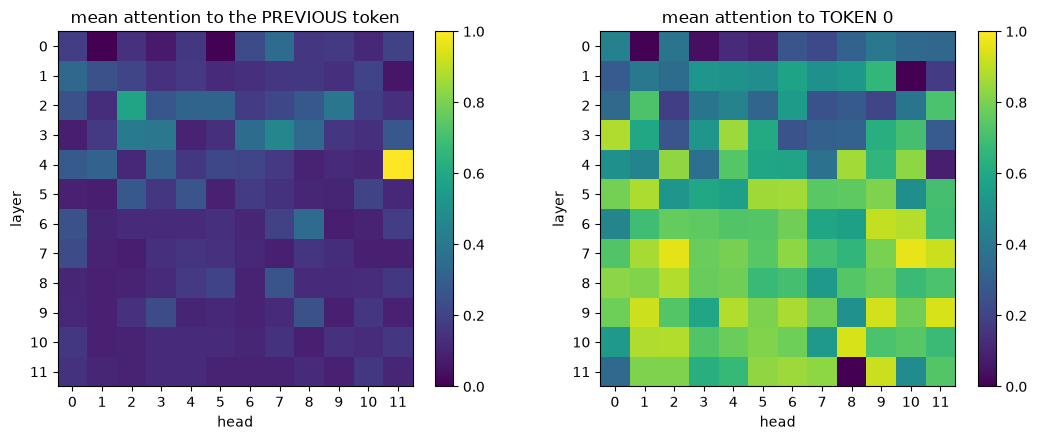

In [32]:
@torch.no_grad()
def get_attention(text: str):
    enc = tok(text, return_tensors="pt")
    out = model(**enc, output_attentions=True)
    assert out.attentions is not None and out.attentions[0] is not None, (
        "no attention weights returned: load the model with attn_implementation='eager'"
    )
    labels = [t.replace("Ġ", "_") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return labels, out.attentions  # 12 tensors, each (batch=1, heads=12, n, n)


TEXT = PROMPT
labels, atts = get_attention(TEXT)
n = len(labels)
print(f"{n} tokens: {labels}")
print(f"{len(atts)} layers; each tensor has shape {tuple(atts[0].shape)} = (batch, heads, query, key)")
print("row sums, layer 0 head 0:", [round(x, 4) for x in atts[0][0, 0].sum(dim=-1).tolist()])

# For every one of the 144 heads: how much attention goes to the PREVIOUS token, and to token 0?
prev_score = torch.zeros(cfg.n_layer, cfg.n_head)
sink_score = torch.zeros(cfg.n_layer, cfg.n_head)
for L in range(cfg.n_layer):
    a = atts[L][0]  # (heads, n, n)
    prev_score[L] = torch.stack([a[:, i, i - 1] for i in range(1, n)]).mean(dim=0)
    sink_score[L] = a[:, 1:, 0].mean(dim=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, score, title in [
    (axes[0], prev_score, "mean attention to the PREVIOUS token"),
    (axes[1], sink_score, "mean attention to TOKEN 0"),
]:
    im = ax.imshow(score.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("head")
    ax.set_ylabel("layer")
    ax.set_xticks(range(cfg.n_head))
    ax.set_yticks(range(cfg.n_layer))
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

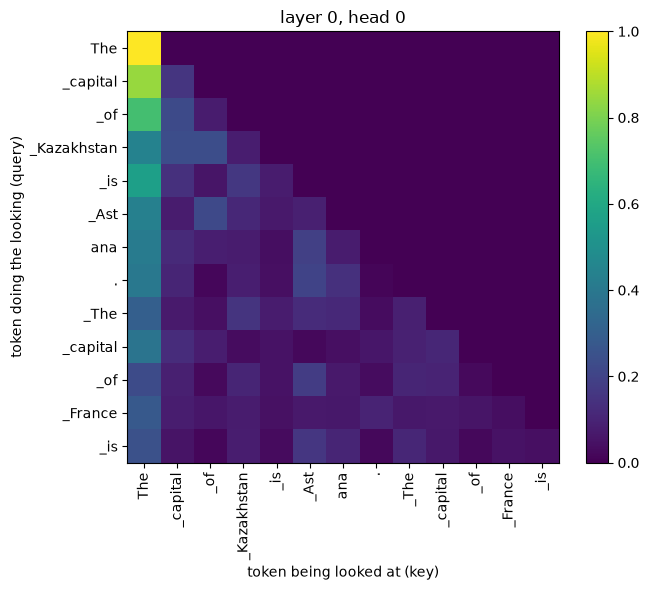

In [33]:
def attention_heatmap(text: str, layer: int, head: int) -> None:
    labels, atts = get_attention(text)
    a = atts[layer][0, head]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(a.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("token being looked at (key)")
    ax.set_ylabel("token doing the looking (query)")
    ax.set_title(f"layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


LAYER, HEAD = 0, 0  # ✏️ TODO: the (layer, head) that the LEFT grid shows as a previous-token head
attention_heatmap(TEXT, LAYER, HEAD)

**✏️ Your answers.**

1. Read the left grid above. Which (layer, head) looks most like a "previous-token" head? Put it into `LAYER, HEAD` in the cell above and re-run it. What pattern do you see in the heatmap, and why is it a diagonal just *below* the main diagonal?
2. Does every head in that layer do the same thing?

> **1.** The clearest previous-token head is **layer 4, head 11** — it puts 1.000 (100%) of its
> attention on the token right before the current one. That's why the heatmap for it shows a
> clean diagonal line just below the main diagonal instead of on it: a line one step below means
> "row i looks at column i-1," i.e. every token is looking at its immediate predecessor.
>
> **2.** No — definitely not. The next closest heads found by the same check were layer 2, head 2
> (0.585) and layer 3, head 7 (0.462), much weaker versions of the pattern in completely different
> layers. So even heads that show some previous-token behavior don't do it nearly as cleanly as
> layer 4/head 11 — it's a specialization of one particular head, not a general property.

In [34]:
# Check yourself: the three heads with the highest previous-token score for this prompt.
for v, idx in zip(*torch.topk(prev_score.flatten(), 3)):
    L, H = divmod(idx.item(), cfg.n_head)
    print(f"layer {L}, head {H}: {v.item():.3f} of its attention goes to the previous token")

layer 4, head 11: 1.000 of its attention goes to the previous token
layer 2, head 2: 0.585 of its attention goes to the previous token
layer 3, head 7: 0.462 of its attention goes to the previous token


most extreme head on the RIGHT grid: layer 7, head 10  (mean attention to token 0 = 0.964)
mean attention to token 0, averaged over the 12 heads of each layer:
   [0.25, 0.42, 0.4, 0.52, 0.57, 0.72, 0.71, 0.81, 0.74, 0.79, 0.75, 0.66]


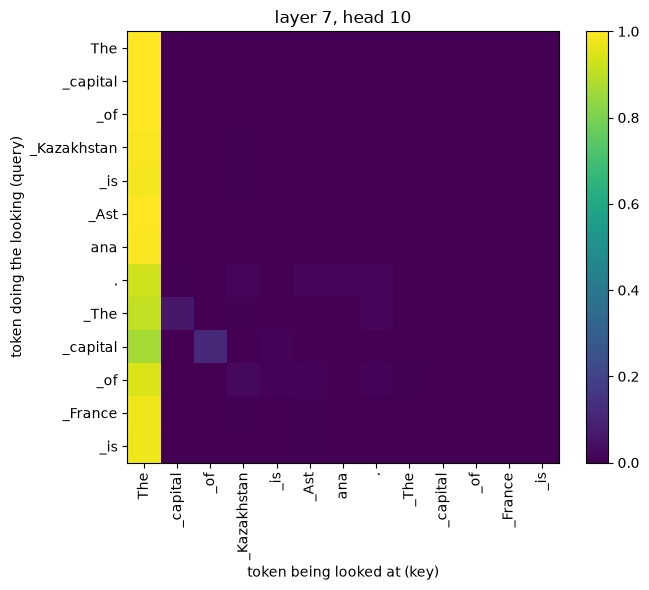

In [35]:
sink_layer, sink_head = divmod(sink_score.argmax().item(), cfg.n_head)
print(f"most extreme head on the RIGHT grid: layer {sink_layer}, head {sink_head}  "
      f"(mean attention to token 0 = {sink_score[sink_layer, sink_head]:.3f})")
print("mean attention to token 0, averaged over the 12 heads of each layer:")
print("  ", [round(x, 2) for x in sink_score.mean(dim=1).tolist()])
attention_heatmap(TEXT, sink_layer, sink_head)

### Two traps

**The bright first column.** In layers 5–10 the *average* head puts roughly 70–80% of its attention on
token 0 (measured above, for this prompt), and the most extreme head puts over 95% there. That is not
"the model is thinking about the word *The*". The usual explanation — which this lab does not test — is that a softmax
row must sum to 1, so a head with nothing useful to look at has to put its weight somewhere, and the first
token is where it goes. Either way, the bright column tells you how the mechanism is built, not what the
first word means. Which head is the most extreme one changes from text to text; the phenomenon does not.

**A weight is not an explanation.** A high attention weight says how much of a token's *value vector* is
averaged in. It does not say how much that token changed the answer. Lecture 3 cited the papers that argue
about this; the heatmap is a picture of a mechanism, not a proof of a reason.

**✏️ Your answer.** Which layers have the highest average attention to token 0? Given the trap above, would you
report "the model focuses on the first word" to a manager? What would you say instead?

> **Answer:** The highest average attention to token 0 shows up in layers 5 through 10ish,
> peaking around layer 7 (0.81) and staying high through layers 8-10 (0.74-0.79); the single most
> extreme head is layer 7, head 10, putting 96.4% of its attention on token 0. I would not tell a
> manager "the model focuses on the first word" — that framing makes it sound semantically
> important, when this looks like a plumbing artifact: softmax rows must sum to 1, so a head with
> nothing useful to attend to dumps its leftover weight onto a fixed, always-available token
> (position 0). What I'd say instead: "several middle-layer heads show a strong attention-sink
> pattern, routing unused attention to the first token — a known artifact of softmax attention,
> not evidence the model treats the first word as meaningful."

## Part 3 — the same model, in Kazakh (5 min)

Lecture 3's claim: Kazakh costs more because of the **table**, not the language. GPT-2's table has only
50,257 entries; how well it covers Russian and Kazakh is what you measure now. Three parallel sentences
(my translations — if you spot an error, say so):

**✏️ Predict first.** Which language needs the most tokens *per character*? Lecture 3 (slide 2) measured Kazakh at
1.7–4.8× the English token count and Russian at 1.2–2.9×, across six tokenizers. Will Kazakh be clearly worse than
Russian on GPT-2 as well?

> **Prediction:** Based on the lecture numbers (Kazakh 1.7-4.8x English, Russian 1.2-2.9x across
> six tokenizers), I'd expect Kazakh to come out clearly worse than Russian on GPT-2 too, maybe
> needing 20-30% more tokens per character than Russian.

In [36]:
SENTENCES = {
    "en": "The capital of Kazakhstan is Astana.",
    "ru": "Столица Казахстана — Астана.",
    "kk": "Қазақстанның астанасы — Астана.",
}

print(f"{'lang':<5}{'chars':>6}{'bytes':>7}{'tokens':>8}{'tokens/char':>13}{'x English':>11}")
en_tokens = len(tok.encode(SENTENCES["en"]))
for lang, s in SENTENCES.items():
    t = len(tok.encode(s))
    print(f"{lang:<5}{len(s):>6}{len(s.encode()):>7}{t:>8}{t / len(s):>13.2f}{t / en_tokens:>11.2f}")

lang  chars  bytes  tokens  tokens/char  x English
en       36     36       8         0.22       1.00
ru       28     53      31         1.11       3.88
kk       31     59      34         1.10       4.25


In [37]:
@torch.no_grad()
def greedy_continue(prompt: str, n_tokens: int = 20) -> str:
    """Slide 14's loop, written out: pick the #1 token, append it, repeat."""
    ids = tok(prompt, return_tensors="pt")["input_ids"]
    for _ in range(n_tokens):
        next_id = model(input_ids=ids).logits[0, -1].argmax()
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
    return tok.decode(ids[0])


for prompt in ["The capital of Kazakhstan is", "Столица Казахстана —", "Қазақстанның астанасы —"]:
    show_next_token(prompt, k=3)
    top1 = int(next_token_logits(prompt).argmax())
    print(f"  #1 token as raw text: {tok.convert_ids_to_tokens(top1)!r}")
    print("  greedy, 20 tokens:", repr(greedy_continue(prompt)))
    print()

prompt: 'The capital of Kazakhstan is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   8.98%   id    262   ' the'
   7.63%   id   1363   ' home'
   5.89%   id    257   ' a'
  top-3 hold 22.5%; the other 50,254 tokens share 77.5%
  #1 token as raw text: 'Ġthe'
  greedy, 20 tokens: "The capital of Kazakhstan is the capital of the country's former Soviet Union, and the country's president, Nursultan Nazar"

prompt: 'Столица Казахстана —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  37.79%   id  12466   ' �'
   2.40%   id    198   '\n'
   2.34%   id    220   ' '
  top-3 hold 42.5%; the other 50,254 tokens share 57.5%
  #1 token as raw text: 'ĠÐ'
  greedy, 20 tokens: 'Столица Казахстана — Столица Казахста'

prompt: 'Қазақстанның астанасы —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.54%   id  12466   ' �'
   4.11%   id    220   ' '
   2.39%   id    198   '\n'
  top-3 hold 29.0%; the other 50,254 tokens share 71.0%
  #1 token as raw te

**✏️ Your answer.** One or two sentences. Look at the `tokens/char` column and at the #1 next token for the
Russian and Kazakh prompts. What does the model see, and why does it break? Is the problem the Kazakh
*language*, or something else? What would you change to fix it?

> **Answer:** Actually my prediction was wrong on the "Kazakh clearly worse" part — Russian and
> Kazakh come out almost identical: 1.11 tokens/char for Russian vs 1.10 for Kazakh (3.88x vs
> 4.25x English respectively). What actually breaks is both non-English languages, not
> specifically Kazakh — the model's #1 next-token prediction for both prompts is dominated by a
> broken replacement character ' �' (37.79% for Russian, 22.54% for Kazakh), and the greedy
> continuations degrade into loops or garbage ('Столица Казахста' repeating, or 'проссии
> проссии про' for Kazakh). So the problem isn't the Kazakh language specifically — GPT-2's
> tokenizer/training data barely covers Cyrillic at all, so both languages get shredded into
> near-meaningless byte pieces. To fix it, you'd need a tokenizer trained on a corpus that
> includes real Cyrillic text so common words get proper multi-character merges instead of
> falling back to raw bytes.

**Summary for grading:**
- Previous-token head: **layer 4, head 11**
- Most extreme "token 0" (attention-sink) head: **layer 7, head 10**

## What you hand in

Download this notebook (*File → Download → .ipynb*) **after** you have run every cell and filled in every ✏️, and upload it to Canvas.

1. The four predictions (Parts 0, 1, temperature, 3), written before you ran the cell, with the measured value next to each.
2. Your one-sentence difference between temperature and top-p.
3. The (layer, head) you found for the previous-token pattern, and the (layer, head) of the most extreme "token 0" head.
4. Your Part 3 answer.

Extension tasks are in the README of this repository. They are optional.